# Comparing predicted protein abundances vs. measured values

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib import gridspec
import numpy as np
import seaborn as sns
from collections import defaultdict

from PAModelpy.utils.pam_generation import set_up_pam

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from Modules.utils.pamparametrizer_analysis import (get_results_from_simulations_fixed_mu, 
                                                    parse_enzyme_complex_id,
                                                    convert_peptide_to_enzyme_concentrations,
                                                    normalize_simulated_protein_concentrations
                                                   )
from Modules.utils.pam_generation import create_pamodel_from_diagnostics_file
from Figures.Scripts.Figure1_iml1515_kcat_analysis import create_cog_barplot


Loading PAModelpy modules version 0.0.5.1
Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-03


In [2]:
NUM_ALT_MODELS =7
PAM_KCAT_FILES = [os.path.join('Results', '3_analysis', 'parameter_files',
                                   f'proteinAllocationModel_EnzymaticData_iML1515_{file_nmbr}.xlsx') for file_nmbr in
                      range(1, NUM_ALT_MODELS+1)]
BEST_INDIV_RESULT_FILES = [os.path.join('Results','2_parametrization','diagnostics',
                                     f'pam_parametrizer_diagnostics_{i}.xlsx') for i in range(1,NUM_ALT_MODELS+1)]
ORI_PAM_KCAT_FILE = os.path.join('Results', '1_preprocessing',
                                 'proteinAllocationModel_iML1515_EnzymaticData_250909.xlsx')
ECOLI_PROTEOME_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes', 'proteome_data_extract_schmidt2016.xlsx')
ECOLI_MODEL_FILE_PATH = os.path.join('Models', 'iML1515.xml')
UNIPROT_INFO_FILE = os.path.join('Data', 'Databases', 'uniprotkb_ecolik12_240726.xlsx')

#average values from Bakken and Olsen (1984); https://pubmed.ncbi.nlm.nih.gov/16346263/
buoyant_volume = 1.09 #g_wetcell/cm^3
dryweight_per_wetweight = 0.3
DRYWEIGHT_PER_LITER = buoyant_volume*1e3*dryweight_per_wetweight #1e3 to convert cm^-3 to dm^-3

locustag_regex =r'\b([b|s]\d{4})\b'

## 1. Get the protein concentrations from the models

In [3]:
substrate_rates = [0.67, 0.5, 0.35]
pam =  set_up_pam(ORI_PAM_KCAT_FILE, ECOLI_MODEL_FILE_PATH, sensitivity=False)
enzymes = [enz.id for enz in pam.enzyme_variables if enz._model is not None]

proteomics_results={'GotEnzymes': get_results_from_simulations_fixed_mu(pamodel=pam,
                                                                           growth_rates = substrate_rates,
                                                                           proteins_to_save = enzymes,
                                                                          method_ids = ['Batch', 'mu_5', 'mu_35']
                                                                          )['proteins']}

for file, label in zip(BEST_INDIV_RESULT_FILES,
                       [f'Alternative {i}' for i in range(1,len(PAM_KCAT_FILES)+1)]
                      ):
    print('\n')
    print(label)
    model = create_pamodel_from_diagnostics_file(file,
                                          pam.copy(copy_with_pickle=True))
#     model = set_up_pam(file, ECOLI_MODEL_FILE_PATH, sensitivity=False)
    enzymes = [enz.id for enz in model.enzyme_variables if enz._model is not None]
    proteomics_results[label] = get_results_from_simulations_fixed_mu(pamodel=model,
                                                                           growth_rates = substrate_rates,
                                                                           proteins_to_save = enzymes,
                                                                          method_ids = ['Batch', 'mu_5', 'mu_35']
                                                                          )['proteins']
    

No enzyme information found for reaction: ICHORS_copy2
No enzyme information found for reaction: ICHORS_copy1
No enzyme information found for reaction: THMDt2pp_copy1
No enzyme information found for reaction: THMDt2pp_copy2
No enzyme information found for reaction: URIt2pp_copy1
No enzyme information found for reaction: URIt2pp_copy2
No enzyme information found for reaction: ADNt2pp_copy1
No enzyme information found for reaction: ADNt2pp_copy2
No enzyme information found for reaction: CYTDt2pp_copy1
No enzyme information found for reaction: CYTDt2pp_copy2
Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Running simulations with a growth rate of 0.67 1/h
The simulated growth rate is 0.09222510963

## 2. Import and parse the proteomics data file
From Schmidt et al (2016). We only use the proteomics measurements for growth on glucose, which are a batch experiment and 2 different dilution rates in a chemostat.

In [4]:
proteome_df = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='ProteinMasses',
                            engine='openpyxl',
                            index_col=0)
proteome_df_metadata = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='GrowthRates',
                            engine='openpyxl',
                            index_col=0)
proteome_df_cog = pd.read_excel(ECOLI_PROTEOME_DATA_PATH,
                            sheet_name='Gene2COG',
                            engine='openpyxl',
                            index_col=0)
proteome_df

,Glucose,LB,Glycerol + AA,Acetate,Fumarate,Glucosamine,Glycerol,Pyruvate,Chemostat µ=0.5,Chemostat µ=0.35,...,Stationary phase 1 day,Stationary phase 3 days,Osmotic-stress glucose,42°C glucose,pH6 glucose,Xylose,Mannose,Galactose,Succinate,Fructose
Bnumber,,,,,,,,,,,,,,,,,,,,,
b3988,0.715349,1.844515,1.159331,0.561253,0.629318,0.853642,0.732347,0.702820,1.230766,1.004203,...,4.466397e-01,4.910739e-01,0.578723,1.026062e+00,0.859739,0.934963,8.757239e-01,5.813814e-01,7.116349e-01,1.162894
b3987,0.989135,2.221614,1.299346,0.665163,0.799515,0.999545,0.936990,0.928398,1.310899,1.096833,...,5.944920e-01,5.565920e-01,0.813304,1.230390e+00,1.007687,1.109002,1.035491e+00,7.049528e-01,9.635688e-01,1.317061
b0118,1.178283,2.575086,2.722244,3.543745,3.023680,2.133445,1.674174,2.543362,2.440666,3.143073,...,1.447816e-01,1.173512e-01,0.436610,7.511055e-01,0.721180,1.038963,2.562241e+00,1.997324e+00,3.032313e+00,1.362394
b2557,0.576304,0.192554,0.548796,0.337313,0.486028,0.459618,0.485143,0.635390,0.536179,0.405983,...,1.449196e-01,1.724214e-01,0.309267,4.423852e-01,0.400793,0.403734,4.139472e-01,3.684797e-01,4.489504e-01,0.564445
b3212,0.774653,0.163742,0.176652,0.369212,0.347026,0.535762,0.597161,0.458132,0.629009,0.530940,...,6.220451e-02,4.961751e-02,0.225865,8.072853e-01,0.737951,0.676351,5.631967e-01,3.788294e-01,4.207655e-01,1.045406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,0.000167,0.001322,NaN,0.000097,0.000504,0.000339,0.000170,0.000183,0.000151,0.000068,...,1.524261e-04,0.000000e+00,0.000010,2.769145e-04,0.000304,NaN,NaN,6.570810e-05,2.050574e-04,NaN
NaN,0.000084,0.000012,0.000002,0.000249,0.000235,0.000125,0.000252,0.000419,0.000644,0.000241,...,6.333976e-07,6.237618e-07,0.000004,9.527910e-06,0.000001,0.000001,1.052190e-06,8.777261e-07,1.026332e-06,0.000001
NaN,0.002472,0.000022,0.000066,0.000770,0.000334,0.000590,0.000709,0.000805,0.000652,0.000320,...,3.374665e-07,1.943465e-04,0.000770,1.372202e-03,0.001054,0.001213,9.174705e-04,3.517107e-04,2.757719e-04,0.001285


In [5]:
#only get the chemostat cultivations on glucose
proteome_glc = proteome_df[['Glucose', 'Chemostat µ=0.5', 'Chemostat µ=0.35']] #unit: fg/cell
proteome_glc.columns = ['Batch', 'mu_5', 'mu_35']
proteome_glc

,Batch,mu_5,mu_35
Bnumber,,,
b3988,0.715349,1.230766,1.004203
b3987,0.989135,1.310899,1.096833
b0118,1.178283,2.440666,3.143073
b2557,0.576304,0.536179,0.405983
b3212,0.774653,0.629009,0.530940
...,...,...,...
NaN,0.000167,0.000151,0.000068
NaN,0.000084,0.000644,0.000241
NaN,0.002472,0.000652,0.000320


### 2.1 Map the gene-identifiers to protein identifiers from uniprot

In [6]:
#use information from uniprot to map the locus tag ids to protein identifiers
uniprot_info_df = pd.read_excel(UNIPROT_INFO_FILE)
# only keep those who are in the model
uniprot_in_model = uniprot_info_df.loc[[prot in proteomics_results['Alternative 1'].enzyme_id.to_list() for prot in uniprot_info_df.Entry]]

#get the gene id from the gene names
uniprot_in_model['b_number'] = uniprot_in_model['Gene Names'].str.extract(locustag_regex)
uniprot_df = uniprot_in_model[['b_number', 'Entry', 'Mass']]
uniprot_df

,b_number,Entry,Mass
2,b2029,P00350,51481
4,b1761,P00370,48581
5,b1109,P00393,47359
6,b3908,P00448,23097
8,b3417,P00490,90522
...,...,...,...
3796,b1400,P77181,21325
3826,b0335,P77495,69351
3843,b1453,P77610,54233
4227,b3488,P37627,61164


In [7]:
proteome_glc_mapped = pd.merge(proteome_glc, uniprot_df, how = 'right', 
                               left_on = 'Bnumber', right_on='b_number')
proteome_glc_mapped

,Batch,mu_5,mu_35,b_number,Entry,Mass
0,1.204216,0.701387,0.444520,b2029,P00350,51481
1,0.511172,0.648978,0.472377,b1761,P00370,48581
2,0.052045,0.051371,0.026041,b1109,P00393,47359
3,0.829572,0.901116,0.790869,b3908,P00448,23097
4,0.041223,0.084767,0.067088,b3417,P00490,90522
...,...,...,...,...,...,...
992,0.000262,0.000419,0.000567,b1400,P77181,21325
993,NaN,NaN,NaN,b0335,P77495,69351
994,NaN,NaN,NaN,b1453,P77610,54233
995,NaN,NaN,NaN,b3488,P37627,61164


## 3. Compare the measured and simulated protein concentations

### 3.1 Convert the measured peptide concentrations to enzyme concentration
The experimental measurements report concentrations for individual peptides, but the model returns concentrations of enzyme units, which can consist out of one or multiple enzymes and/or enzyme complexes. Therefore, we calculate the enzyme concentrations as follows:

- **Homomeric enzymes** retain their original concentrations.
- **Enzyme complexes** take the minimum concentration of all participating peptides.
- **Isozymes** take the sum concentration of all isozymes

The masses of the enzymes are stored in the ActiveEnzymes information excel sheet. The mass of each functional enzymatic unit is calculated as follows:

- **Homomeric enzymes** retain their original mass.
- **Enzyme complexes** take the sum of the mass of all participating peptides.
- **Isozymes** retain their original mass.

In [8]:
#information about gpr relationships is stored in the model's ActiveEnzyme sheet
enzyme_db = pd.read_excel(ORI_PAM_KCAT_FILE, sheet_name = 'ActiveEnzymes')

proteomics_per_enzyme = convert_peptide_to_enzyme_concentrations(
    proteome_glc_mapped.rename({'Entry': 'enzyme_id'}, axis=1),
    enzyme_db, 
    concentration_columns = list(proteome_glc.columns)
).dropna()

#ActiveEnzyme sheets also contains the correct molar masses
masses_per_enzyme = enzyme_db[['enzyme_id', 'molMass']].drop_duplicates()

proteomics_per_enzyme = proteomics_per_enzyme.merge(masses_per_enzyme, on='enzyme_id')

proteomics_per_enzyme

,rxn_id,enzyme_id,Batch,mu_5,mu_35,enzyme_type,molMass
0,12DGR120tipp,Enzyme_12DGR120tipp,0.000000,0.000000,0.000000e+00,Complex,39959.4825
1,12DGR140tipp,Enzyme_12DGR140tipp,0.000000,0.000000,0.000000e+00,Complex,39959.4825
2,12DGR141tipp,Enzyme_12DGR141tipp,0.000000,0.000000,0.000000e+00,Complex,39959.4825
3,12DGR160tipp,Enzyme_12DGR160tipp,0.000000,0.000000,0.000000e+00,Complex,39959.4825
4,12DGR161tipp,Enzyme_12DGR161tipp,0.000000,0.000000,0.000000e+00,Complex,39959.4825
...,...,...,...,...,...,...,...
2555,XYLabcpp,P0AGI4_P37387_P37388,0.000000,0.000000,0.000000e+00,Complex,133235.0000
2556,XYLt2pp,P0AGF4,0.000076,0.000041,8.089220e-07,Homomer,53608.0000
2557,YUMPS,P33025,0.000774,0.006678,1.492201e-02,Isozyme,32910.0000
2558,YUMPS,P33025,0.000774,0.006678,1.492201e-02,Isozyme,32910.0000


### 3.2 Normalize the measured protein concentrations
From fg/cell to mmol/gCDW to g_p/g_totalprotein, using the measured cell volume, protein masses and an estimate on the amount of gCDW per volume of cells from [Bakken and Olsen (1983)](https://pmc.ncbi.nlm.nih.gov/articles/PMC242437/?page=1)

In [9]:
proteome_glc_normalized = proteomics_per_enzyme.copy()
proteome_glc_mmol = proteomics_per_enzyme.copy()
gcdw_per_liter = 1

#proteomics data
for exp, col in zip(['Glucose', 'Chemostat µ=0.5', 'Chemostat µ=0.35'], proteome_glc.columns):
    fl_per_cell = proteome_df_metadata.Cell_volume.loc[exp] #TODO
    #units are in fg/cell, cell * fl/cell * gcdw/l -> fgcdw
    proteome_glc_mmol[col] = (proteomics_per_enzyme[col]/ 
                              (fl_per_cell*DRYWEIGHT_PER_LITER)) # cell * fl/cell * gcdw/l -> fgcdw
    
    #need to sum all measured proteins while ignoring double entries because of isozymes
    total_protein_content = proteome_glc_mmol.drop_duplicates('rxn_id')[col].sum()
    proteome_glc_normalized[col] = proteome_glc_mmol[col].div(total_protein_content)

    
#convert to long_format
proteome_glc_long = pd.melt(proteome_glc_normalized, value_vars = ['Batch', 'mu_5', 'mu_35'], 
                            id_vars = ['enzyme_id', 'rxn_id'],
                           var_name = 'experiment', value_name = 'fraction')
#sum all fractions for a single protein
# proteome_glc_long =  proteome_glc_long.groupby(['enzyme_id', 'experiment']).sum().reset_index()
proteome_glc_long

,enzyme_id,rxn_id,experiment,fraction
0,Enzyme_12DGR120tipp,12DGR120tipp,Batch,0.000000e+00
1,Enzyme_12DGR140tipp,12DGR140tipp,Batch,0.000000e+00
2,Enzyme_12DGR141tipp,12DGR141tipp,Batch,0.000000e+00
3,Enzyme_12DGR160tipp,12DGR160tipp,Batch,0.000000e+00
4,Enzyme_12DGR161tipp,12DGR161tipp,Batch,0.000000e+00
...,...,...,...,...
7675,P0AGI4_P37387_P37388,XYLabcpp,mu_35,0.000000e+00
7676,P0AGF4,XYLt2pp,mu_35,3.375278e-09
7677,P33025,YUMPS,mu_35,6.226301e-05
7678,P33025,YUMPS,mu_35,6.226301e-05


### 3.3 Normalize the simulated protein concentrations
From mmol/gCDW to g_p/g_totalprotein. The total protein concentration is corrected for the amount of unused enzymes at the growth rate in which the experiment was performed. The model already correclty determines the concentrations for homomers and enzyme complexes. In order to compare the simulated concentrations for isozymes, we sum the concentration of all alternative enzymes for a single reaction.

In [10]:
# Store results in a list
prot_predicted_long_list = []
molmasses_df = proteomics_per_enzyme[['enzyme_id', 'molMass']].drop_duplicates()

pamodel = set_up_pam(ORI_PAM_KCAT_FILE, ECOLI_MODEL_FILE_PATH, sensitivity=False)

for model_name, protein_df in proteomics_results.items():
    print(f"Processing {model_name}...")
    protein_df = pd.merge(protein_df, molmasses_df, on='enzyme_id')
    #this function also corrects the concentration units from mmol to g
    protein_df = normalize_simulated_protein_concentrations(protein_df,
                                                            enzyme_db,
                                                            pamodel.sectors.get_by_id('UnusedEnzymeSector'))
    protein_df['model'] = model_name
    prot_predicted_long_list.append(protein_df)

# Merge all at once
prot_predicted_long = pd.concat(prot_predicted_long_list, ignore_index=True)

prot_predicted_long

No enzyme information found for reaction: ICHORS_copy2
No enzyme information found for reaction: ICHORS_copy1
No enzyme information found for reaction: THMDt2pp_copy1
No enzyme information found for reaction: THMDt2pp_copy2
No enzyme information found for reaction: URIt2pp_copy1
No enzyme information found for reaction: URIt2pp_copy2
No enzyme information found for reaction: ADNt2pp_copy1
No enzyme information found for reaction: ADNt2pp_copy2
No enzyme information found for reaction: CYTDt2pp_copy1
No enzyme information found for reaction: CYTDt2pp_copy2
Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Processing GotEnzymes...
Processing Alternative 1...
Processing Alternative 2...
Processing A

,enzyme_id,rxn_id,normalized_fraction,method,enzyme_type,model
0,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,GotEnzymes
1,Enzyme_12DGR140tipp,12DGR140tipp,0.0,Batch,Complex,GotEnzymes
2,Enzyme_12DGR141tipp,12DGR141tipp,0.0,Batch,Complex,GotEnzymes
3,Enzyme_12DGR160tipp,12DGR160tipp,0.0,Batch,Complex,GotEnzymes
4,Enzyme_12DGR161tipp,12DGR161tipp,0.0,Batch,Complex,GotEnzymes
...,...,...,...,...,...,...
86083,P37617,ZN2abcpp,0.0,mu_5,Homomer,Alternative 7
86084,P69380,ZN2t3pp,0.0,mu_5,Isozyme,Alternative 7
86085,P75757,ZN2t3pp,0.0,mu_5,Isozyme,Alternative 7
86086,P0A8H3,ZN2tpp,0.0,mu_5,Homomer,Alternative 7


### 3.3 combine the protein concentrations of measurements and simulations

In [11]:
all_proteins_long = pd.merge(prot_predicted_long, proteome_glc_long.rename({'experiment': 'method'}, axis = 1), 
                             on=['method', 'enzyme_id', 'rxn_id'], how = 'inner')
all_proteins_long

,enzyme_id,rxn_id,normalized_fraction,method,enzyme_type,model,fraction
0,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,GotEnzymes,0.0
1,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,Alternative 1,0.0
2,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,Alternative 2,0.0
3,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,Alternative 3,0.0
4,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,Alternative 4,0.0
...,...,...,...,...,...,...,...
94171,P0A9X1_P39172_P39832,ZNabcpp,0.0,mu_5,Complex,Alternative 3,0.0
94172,P0A9X1_P39172_P39832,ZNabcpp,0.0,mu_5,Complex,Alternative 4,0.0
94173,P0A9X1_P39172_P39832,ZNabcpp,0.0,mu_5,Complex,Alternative 5,0.0
94174,P0A9X1_P39172_P39832,ZNabcpp,0.0,mu_5,Complex,Alternative 6,0.0


## 4. Compare the measured with simulated protein abundances

In [12]:
def create_joyplot(input_df,col_to_plot, col_to_hue,label_names: list[str], title,
                   other_colors={},result_fig_file:str=None):    
    # Set up the seaborn theme
    input_df['log'] = np.log10(input_df[col_to_plot])
    sns.set_theme(style="whitegrid")
    # Get unique categories
    unique_categories = input_df[col_to_hue].unique()

    # Generate a base colormap from "coolwarm"
    cmap = plt.get_cmap("coolwarm", len(unique_categories))
    base_colors = {category: cmap(i) for i, category in enumerate(unique_categories)}

    # If other_colors is provided, override colors
    if other_colors:
        for category, color in other_colors.items():
            if category in base_colors:
                base_colors[category] = color  # Replace default color with manual color

    # Use the updated color dictionary as the palette
    g = sns.FacetGrid(input_df, row=col_to_hue, hue=col_to_hue, aspect=15, height=0.6, palette=base_colors)

    # Add KDE plots to the grid
    g.map(sns.kdeplot, 'log', fill=True, alpha=0.7, linewidth=1.5)

    # Add a white line to separate KDE plots for better visibility
    g.map(sns.kdeplot, 'log', color="white", linewidth=1)

    # Set y-labels using the provided label names
    for ax, label in zip(g.axes.flat, label_names):
        ax.text(0, 0, label, ha="right", va="bottom", fontsize=12, color="black", transform=ax.transAxes)

    # Format x-axis to display scientific notation (10^x)
    for ax in g.axes.flat:
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))

    # Customize appearance
    g.fig.subplots_adjust(hspace=-0.6)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)

    # Add a title and x-axis label
    #plt.xscale('log')
    plt.title(title, fontsize=14, pad=20)
    plt.xlabel(r"Normalized peptide concentration [log10($g_{protein}/\sum g_{protein}$)]", fontsize=12)

    # Tight layout for better spacing
    plt.tight_layout()

    # Save the plot
    if result_fig_file is not None:
        plt.savefig(result_fig_file, dpi=300)
    else:
        plt.show()

In [13]:
all_proteins_per_configs = all_proteins_long.copy()
# Create a copy of the existing dataframe with modifications
measurement_df = all_proteins_per_configs[['enzyme_id', 'fraction', 'method', 'enzyme_type']].copy()
measurement_df['model'] = 'Measurements'  # Assign 'measurement' to the model column
measurement_df.rename(columns={'fraction': 'normalized_fraction'}, inplace=True)  # Align column names

# Append the new rows to the original dataframe
all_proteins_per_configs = pd.concat([all_proteins_per_configs, measurement_df], ignore_index=True)
all_proteins_per_configs

,enzyme_id,rxn_id,normalized_fraction,method,enzyme_type,model,fraction
0,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,GotEnzymes,0.0
1,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,Alternative 1,0.0
2,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,Alternative 2,0.0
3,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,Alternative 3,0.0
4,Enzyme_12DGR120tipp,12DGR120tipp,0.0,Batch,Complex,Alternative 4,0.0
...,...,...,...,...,...,...,...
188347,P0A9X1_P39172_P39832,NaN,0.0,mu_5,Complex,Measurements,NaN
188348,P0A9X1_P39172_P39832,NaN,0.0,mu_5,Complex,Measurements,NaN
188349,P0A9X1_P39172_P39832,NaN,0.0,mu_5,Complex,Measurements,NaN
188350,P0A9X1_P39172_P39832,NaN,0.0,mu_5,Complex,Measurements,NaN


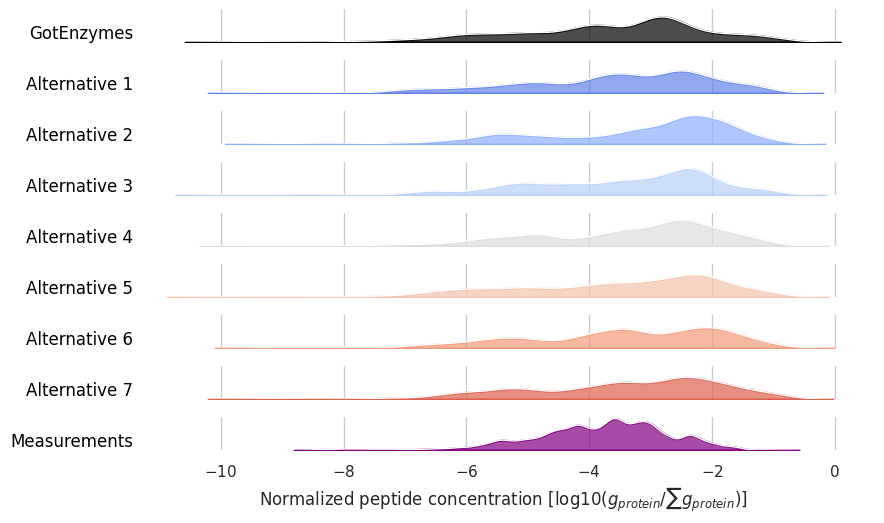

In [14]:
create_joyplot(input_df=all_proteins_per_configs,
                   col_to_plot = 'normalized_fraction', 
                   col_to_hue = 'model',
                   label_names=all_proteins_per_configs.model.unique(),
                   title = '',
               other_colors = {'GotEnzymes':'black', 'Measurements':'purple'},
               result_fig_file = os.path.join('Figures', 'SuppFig_protein_concentration_joyplot.png')
              )

## 5 COG analysis

### 5.1 Match the protein information to the COG annotation

In [15]:
#match the cog classes to the protein concentrations
total_proteome_df_cog = all_proteins_long.merge(uniprot_df[['Entry', 'b_number']], 
                                                left_on = 'enzyme_id', 
                                                right_on = 'Entry')
total_proteome_df_cog = total_proteome_df_cog.merge(proteome_df_cog[['COG Name']], 
                                                left_on = 'b_number', 
                                                right_index=True)
total_proteome_df_cog = total_proteome_df_cog.drop_duplicates()

In [16]:
from Figures.Scripts.Figure1_iml1515_kcat_analysis import create_cog_barplot

total_proteome_df_cog_diff = total_proteome_df_cog.drop_duplicates()
total_proteome_df_cog_diff['difference'] = total_proteome_df_cog_diff.normalized_fraction-total_proteome_df_cog_diff.fraction

# Step 1: Compute the sums of positive and negative changes
total_proteome_df_cog_diff['positive_change'] = total_proteome_df_cog_diff['difference'].apply(lambda x: x if x > 0 else 0)
total_proteome_df_cog_diff['negative_change'] = total_proteome_df_cog_diff['difference'].apply(lambda x: x if x < 0 else 0)

    # Sum of changes grouped by alternative and COG description
cog_summary_diff = total_proteome_df_cog_diff.groupby(['COG Name', 'model']).agg({
        'positive_change': 'sum',
        'negative_change': 'sum'
    }).reset_index()

    # Reshape the data for plotting
cog_summary_long_diff = pd.melt(
        cog_summary_diff,
        id_vars=['COG Name', 'model'],
        value_vars=['positive_change', 'negative_change'],
        var_name='Change Type',
        value_name='Change'
    ).rename({'COG Name':'COG description', 'model':'alternative'}, axis=1)



### 5.2 Analyse the changes in enzyme abundance per COG

In [17]:
measured_proteins =  total_proteome_df_cog.drop_duplicates(['enzyme_id', 'method'])
measured_proteins['model'] = 'Measurements'
measured_proteins['fraction'] = measured_proteins['normalized_fraction']
total_proteome_df_cog_sum = pd.concat([total_proteome_df_cog, measured_proteins])
total_proteome_df_cog_sum = total_proteome_df_cog_sum.drop_duplicates()

# Step 1: Compute the sums of positive and negative changes
total_proteome_df_cog_sum['positive_change'] = total_proteome_df_cog_sum['fraction'].apply(lambda x: x if x > 0 else 0)
total_proteome_df_cog_sum['negative_change'] = total_proteome_df_cog_sum['fraction'].apply(lambda x: x if x < 0 else 0)

# Compute the sum of 'fraction' for each model
total_proteome_df_cog_sum['fraction_sums'] = total_proteome_df_cog_sum.groupby(['model'])['fraction'].transform('sum')
total_proteome_df_cog_sum['positive_change'] =total_proteome_df_cog_sum['positive_change']/total_proteome_df_cog_sum['fraction_sums']
# Aggregate the data and divide by the fraction sum per model

cog_summary_sum = total_proteome_df_cog_sum.groupby(['COG Name', 'model']).agg({
    'positive_change': 'sum',
    'negative_change': 'sum'
}).reset_index()

plotting_threshold = 0.075

    # Reshape the data for plotting
cog_summary_long_sum = pd.melt(
        cog_summary_sum,
        id_vars=['COG Name', 'model'],
        value_vars=['positive_change', 'negative_change'],
        var_name='Change Type',
        value_name='Change'
    ).rename({'COG Name':'COG description', 'model':'alternative'}, axis=1)


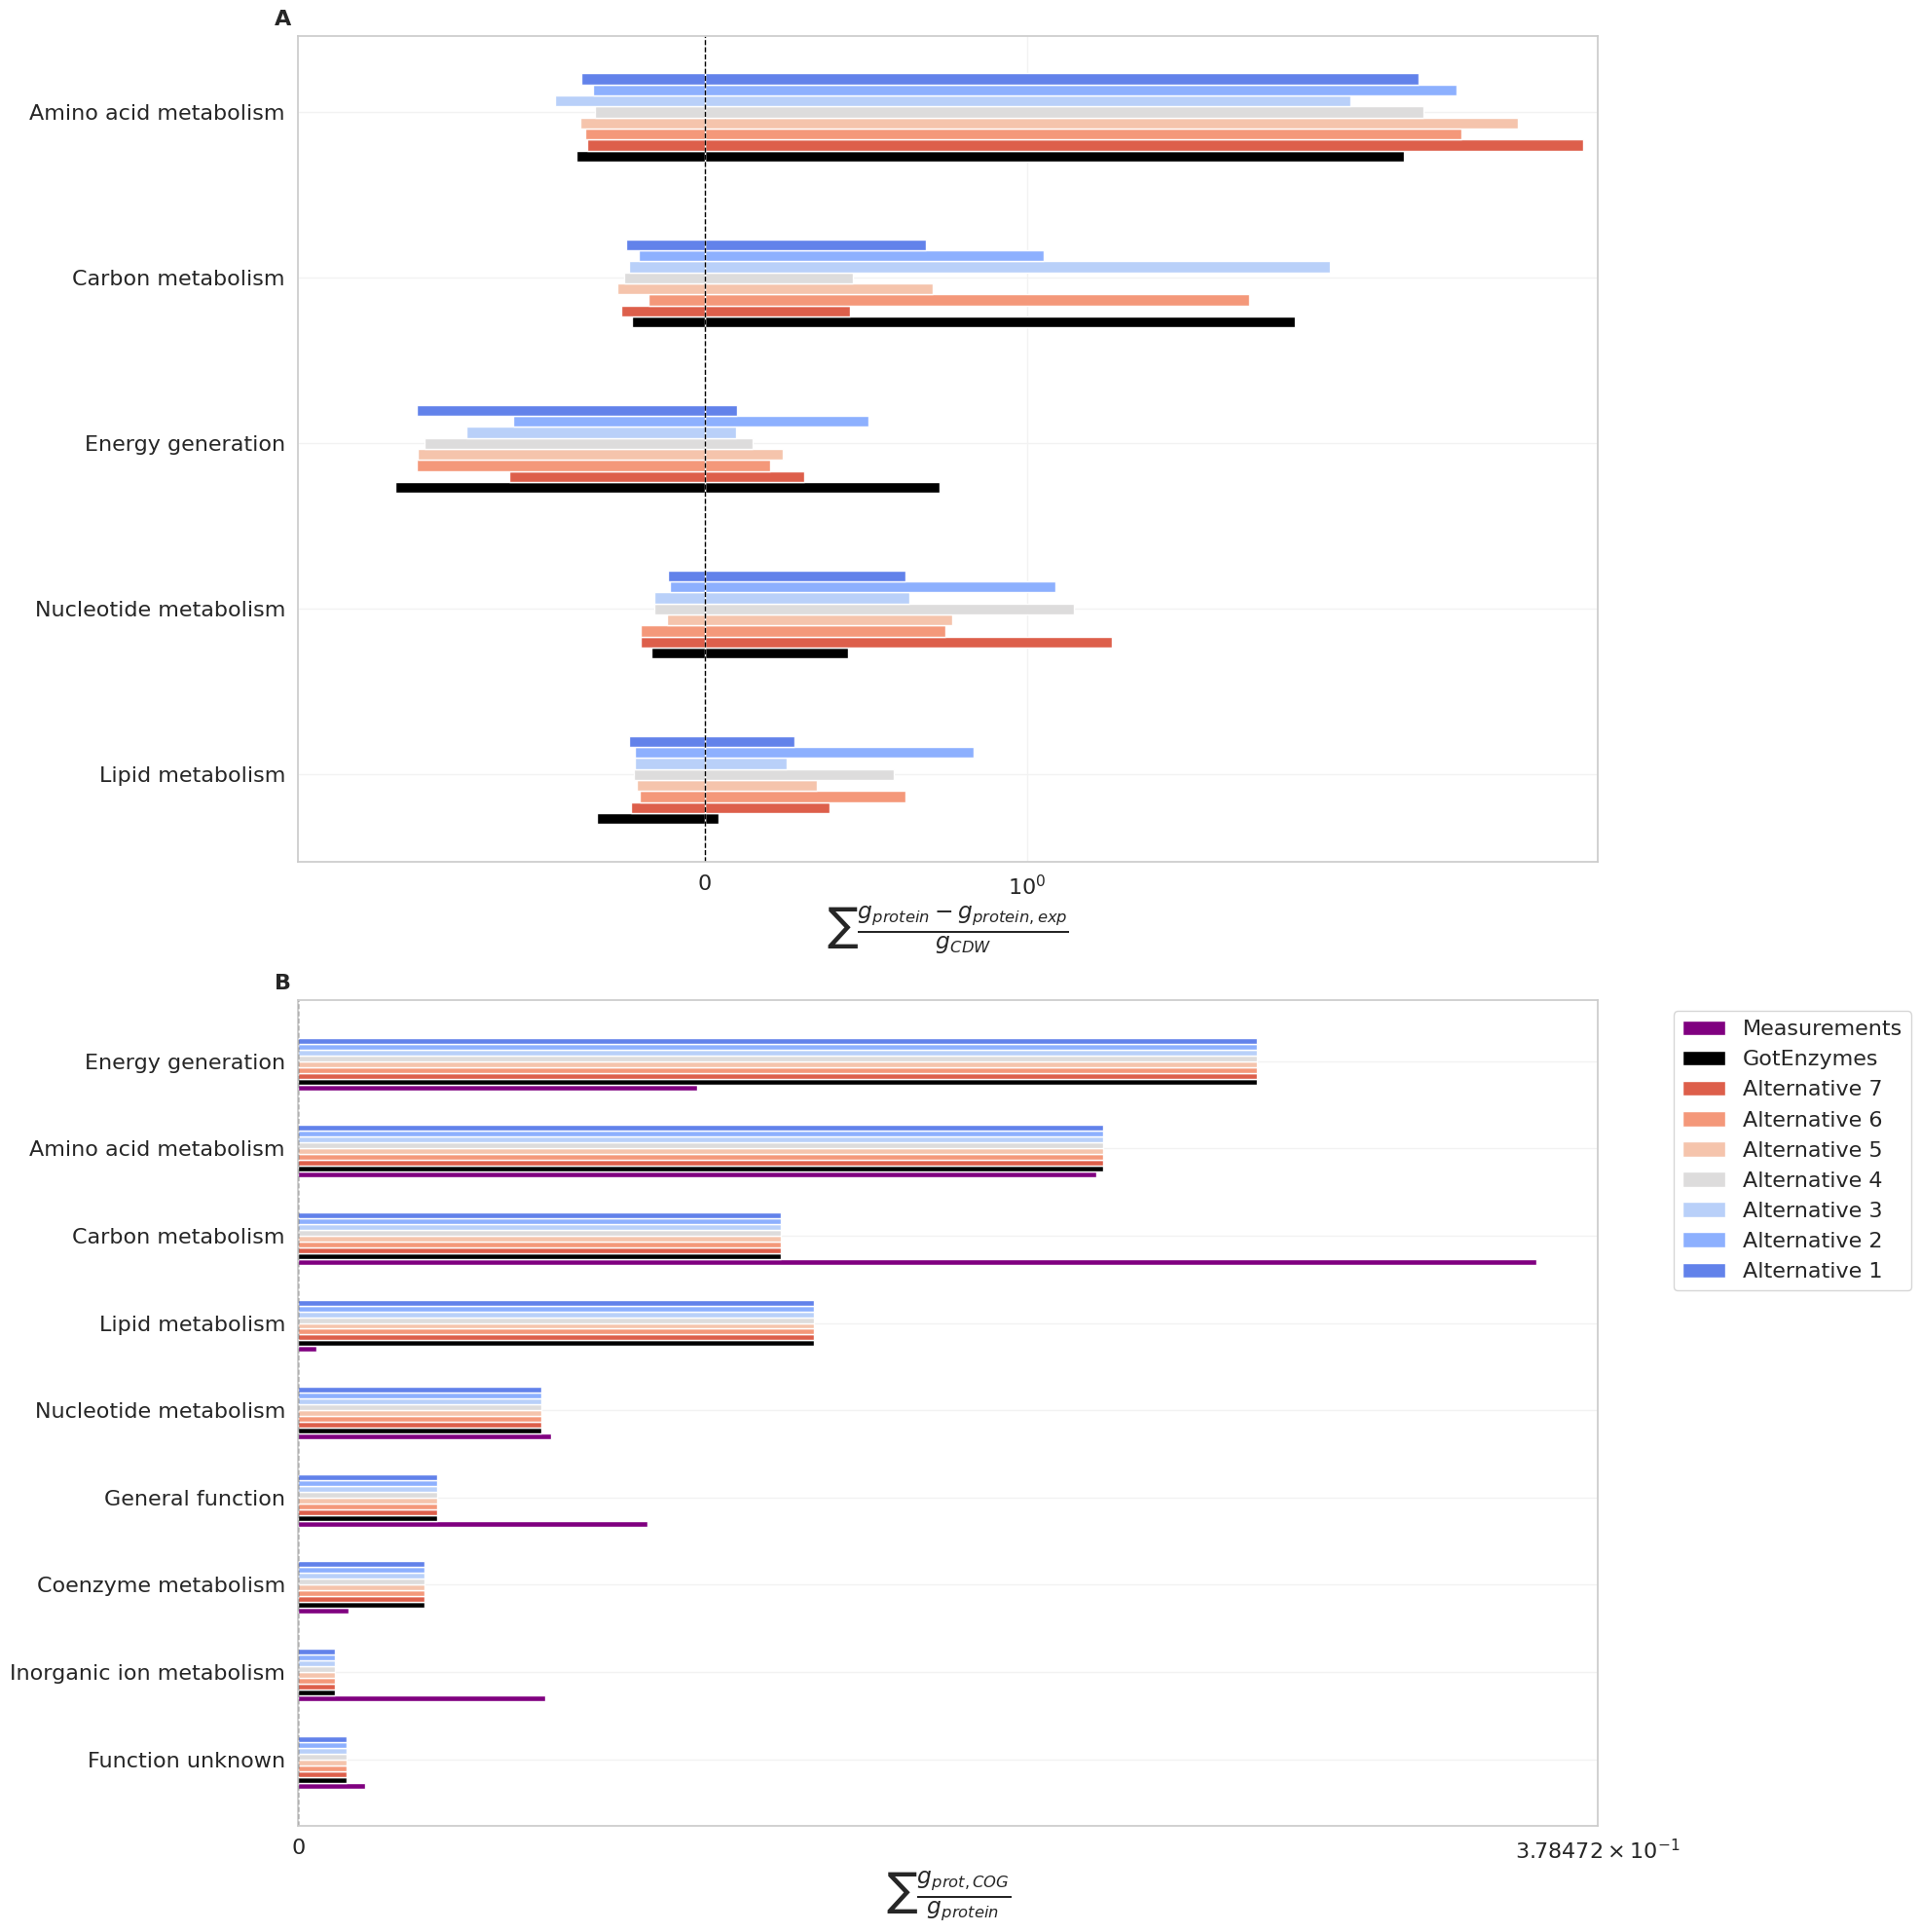

In [18]:
fig = plt.figure(figsize=(20, 20))
fontsize = 16

gs = gridspec.GridSpec(2,1)
ax1 = fig.add_subplot(gs[0])
create_cog_barplot(cog_summary_long_diff, ax1, plotting_threshold=5,legend=False, fontsize=fontsize,
                  other_colors = {'GotEnzymes':'black'}, xlabel = r'$\sum\frac{g_{protein}-g_{protein,exp}}{g_{CDW}}$')
ax1.set_xscale('symlog')

ax2 = fig.add_subplot(gs[1])
create_cog_barplot(cog_summary_long_sum, ax2, plotting_threshold=0.075,legend=True, fontsize=fontsize,
                   xlabel = r'$\sum\frac{g_{prot,COG}}{g_{protein}}$',
                  other_colors = {'GotEnzymes':'black', 'Measurements': 'purple'})

annotations = ["A", "B"]
for ax, label in zip(fig.axes, annotations):
    ax.annotate(label, xy=(0, 1), xycoords="axes fraction",
                fontsize=fontsize, fontweight='bold',
                xytext=(-5, 5), textcoords="offset points",
                ha="right", va="bottom")
fig.tight_layout()

fig.savefig(os.path.join('Figures', 'SuppFig_protein_conc_cog.png'))